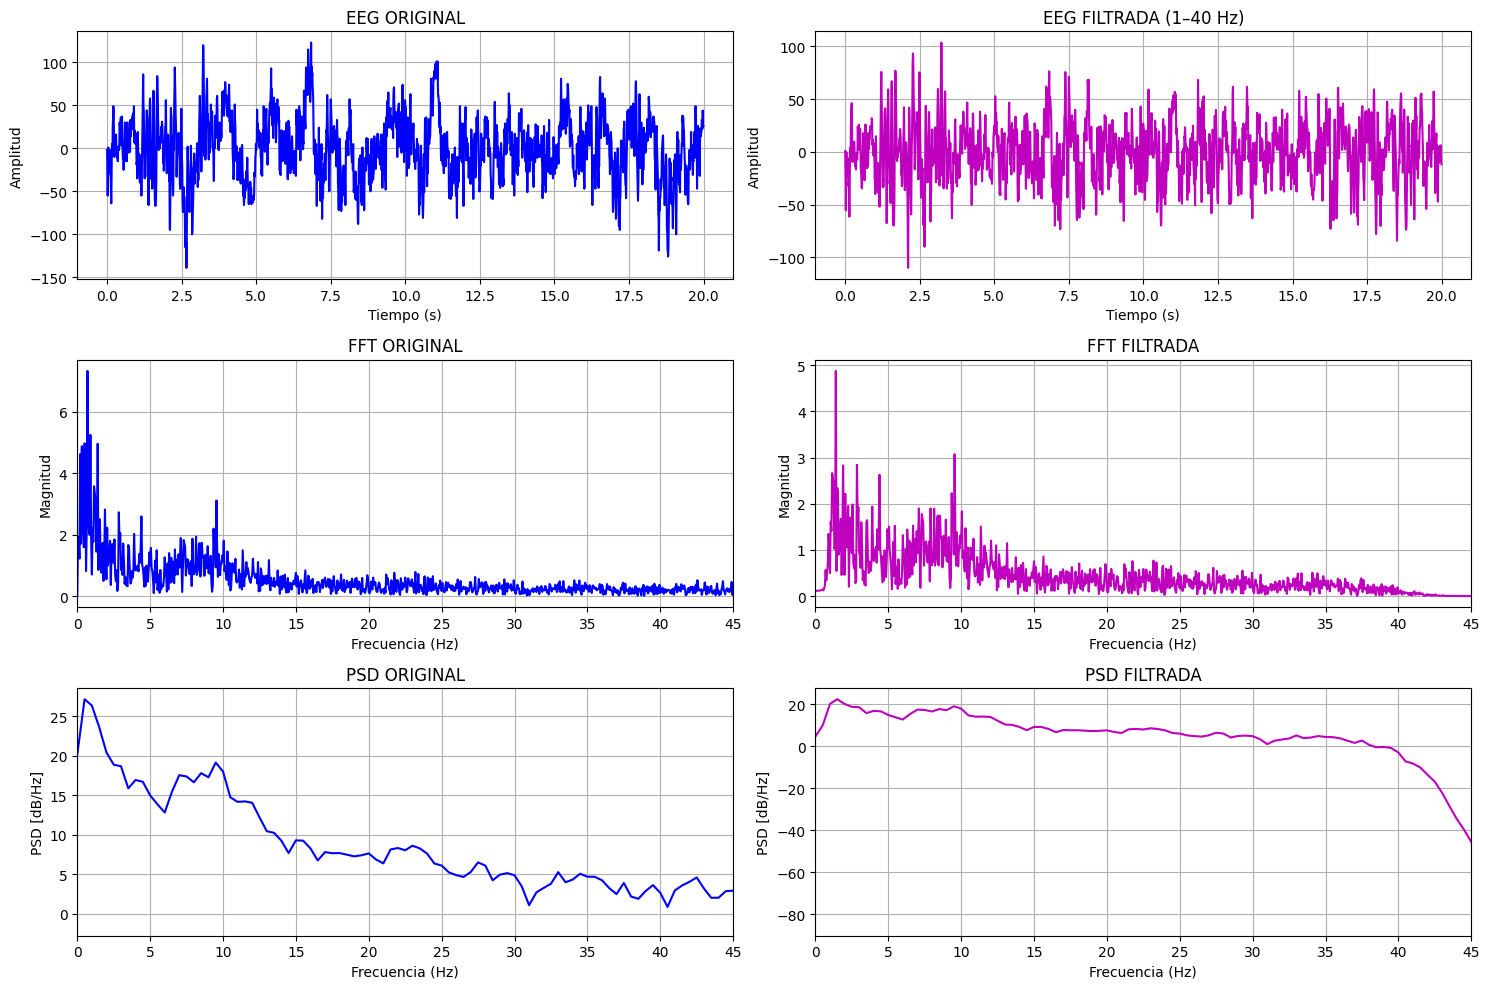

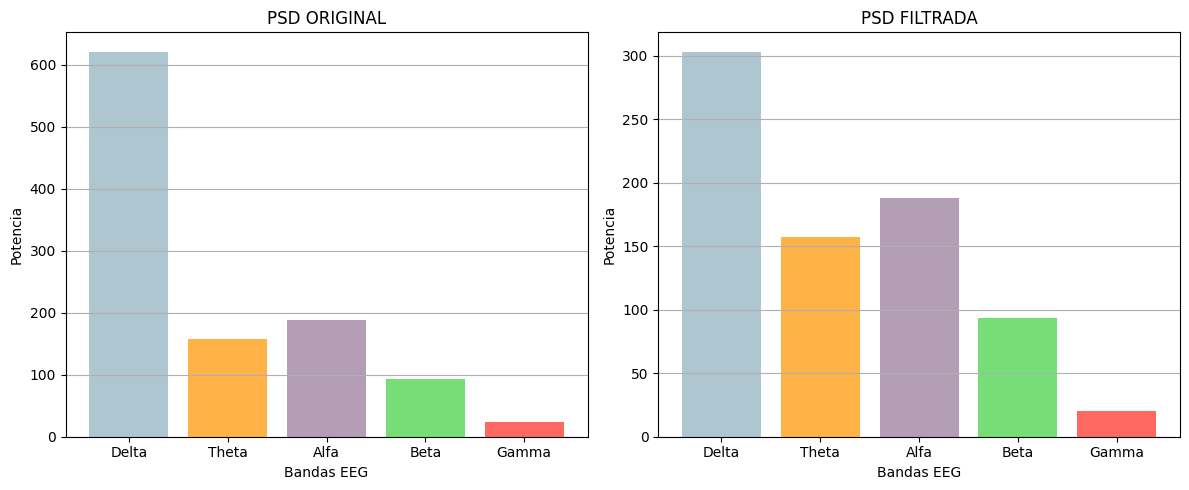

In [50]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt, welch

# Cargamos los datos del archivo .txt de OpenSignals
datos = np.loadtxt("Basal_1.txt", delimiter=None, comments="#")

eeg = datos[:, 5]

def fft(signal, fs):
    N = len(signal)
    fft_vals = np.fft.rfft(signal)
    fft_mag = np.abs(fft_vals) / N
    fft_db = 20 * np.log10(fft_mag + 1e-12)
    freqs = np.fft.rfftfreq(N, d=1/fs)
    return freqs, fft_mag, fft_db

fs = 100
inicio = 0
fin = int(20 * fs)
eeg_segment = eeg[inicio:fin]

# Tiempo
N = len(eeg_segment)
t = np.arange(N) / fs
eeg_segment = eeg_segment - np.mean(eeg_segment)

# Filtro pasa banda
lowcut = 1
highcut = 40
b, a = butter(4,[lowcut/(fs/2), highcut/(fs/2)],btype='band')
filtered_eeg = filtfilt(b, a, eeg_segment)

# FFT
f_orig, fft_mag_orig, fft_db_orig = fft(eeg_segment,fs)
f_filt, fft_mag_filt, fft_db_filt = fft(filtered_eeg,fs)

# PSD
f_psd_orig, psd_orig = welch(eeg_segment,fs=fs,nperseg=fs*2)
f_psd_filt, psd_filt = welch(filtered_eeg,fs=fs,nperseg=fs*2)

psd_orig_db = 10 * np.log10(psd_orig + 1e-12)
psd_filt_db = 10 * np.log10(psd_filt + 1e-12)

# Gráficos

plt.figure(figsize=(15,10))

# EEG en el tiempo
# sin filtrar
plt.subplot(3,2,1)
plt.plot(t, eeg_segment,'b')
plt.title("EEG original")
plt.xlabel("Tiempo (s)")
plt.ylabel("Amplitud")
plt.grid()

# Filtrada
plt.subplot(3,2,2)
plt.plot(t, filtered_eeg,'m')
plt.title("EEG filtrada (1–40 Hz)")
plt.xlabel("Tiempo (s)")
plt.ylabel("Amplitud")
plt.grid()

# FFT
# sin filtrar
plt.subplot(3,2,3)
plt.plot(f_orig, fft_mag_orig,'b')
plt.title("FFT original")
plt.xlabel("Frecuencia (Hz)")
plt.ylabel("Magnitud")
plt.xlim(0,45)
plt.grid()

# Filtrada
plt.subplot(3,2,4)
plt.plot(f_filt, fft_mag_filt,'m')
plt.title("FFT filtrada")
plt.xlabel("Frecuencia (Hz)")
plt.ylabel("Magnitud")
plt.xlim(0,45)
plt.grid()

# PSD
# sin filtro
plt.subplot(3,2,5)
plt.plot(f_psd_orig, psd_orig_db,'b')
plt.title("PSD original")
plt.xlabel("Frecuencia (Hz)")
plt.ylabel("PSD [dB/Hz]")
plt.xlim(0,45)
plt.grid()

# Filtrada
plt.subplot(3,2,6)
plt.plot(f_psd_filt, psd_filt_db,'m')
plt.title("PSD filtrada")
plt.xlabel("Frecuencia (Hz)")
plt.ylabel("PSD [dB/Hz]")
plt.xlim(0,45)
plt.grid()

plt.tight_layout()
plt.show()

# POTENCIA POR BANDAS
bandas = {"Delta": (0.5, 4), "Theta": (4, 8), "Alfa": (8, 12),
          "Beta": (13, 30),"Gamma": (30, 40)}
potencias_orig = []
potencias_filt = []

for fmin, fmax in bandas.values():

    # sin filtro
    idx_orig = np.logical_and(f_psd_orig >= fmin,f_psd_orig <= fmax)
    potencia_orig = np.trapezoid(psd_orig[idx_orig],f_psd_orig[idx_orig])
    potencias_orig.append(potencia_orig)

    # Filtrada
    idx_filt = np.logical_and(f_psd_filt >= fmin,f_psd_filt <= fmax)
    potencia_filt = np.trapezoid(psd_filt[idx_filt],f_psd_filt[idx_filt])
    potencias_filt.append(potencia_filt)


colores = ["#AEC6CF", "#FFB347", "#B39EB5", "#77DD77", "#FF6961"]
# Psd barras
plt.figure(figsize=(12,5))

#sin filtro
plt.subplot(1,2,1)
plt.bar(bandas.keys(),potencias_orig,color=colores)
plt.title("PSD original")
plt.xlabel("Bandas EEG")
plt.ylabel("Potencia")
plt.grid(axis="y")

# Filtrada
plt.subplot(1,2,2)
plt.bar(bandas.keys(), potencias_filt,color=colores)
plt.title("PSD filtrada")
plt.xlabel("Bandas EEG")
plt.ylabel("Potencia")
plt.grid(axis="y")

plt.tight_layout()
plt.show()

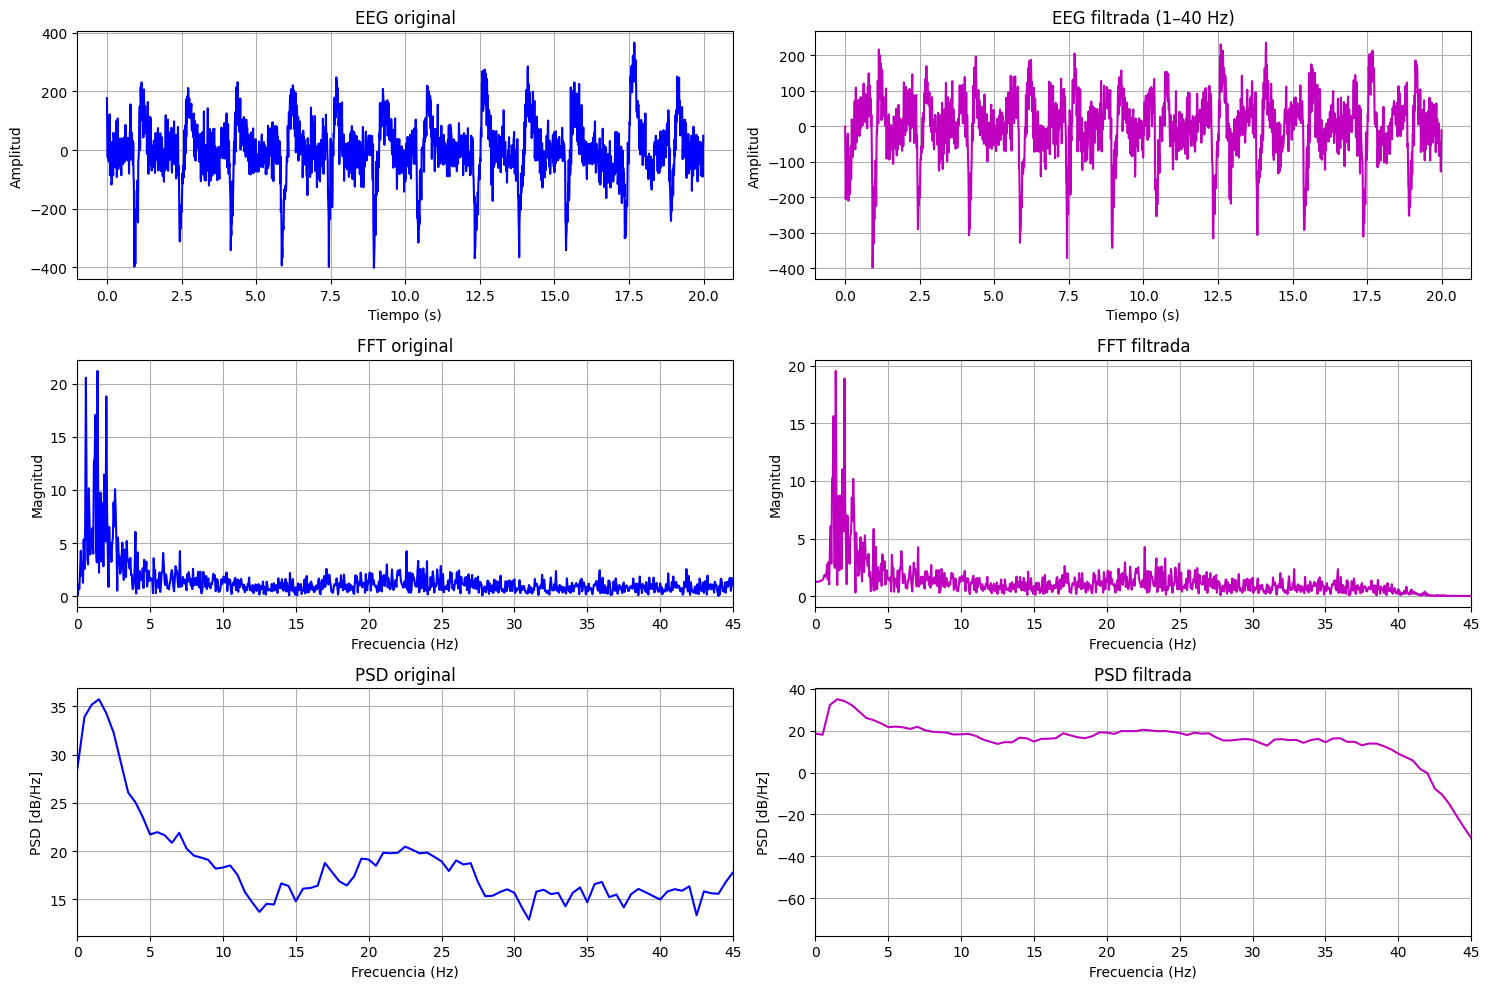

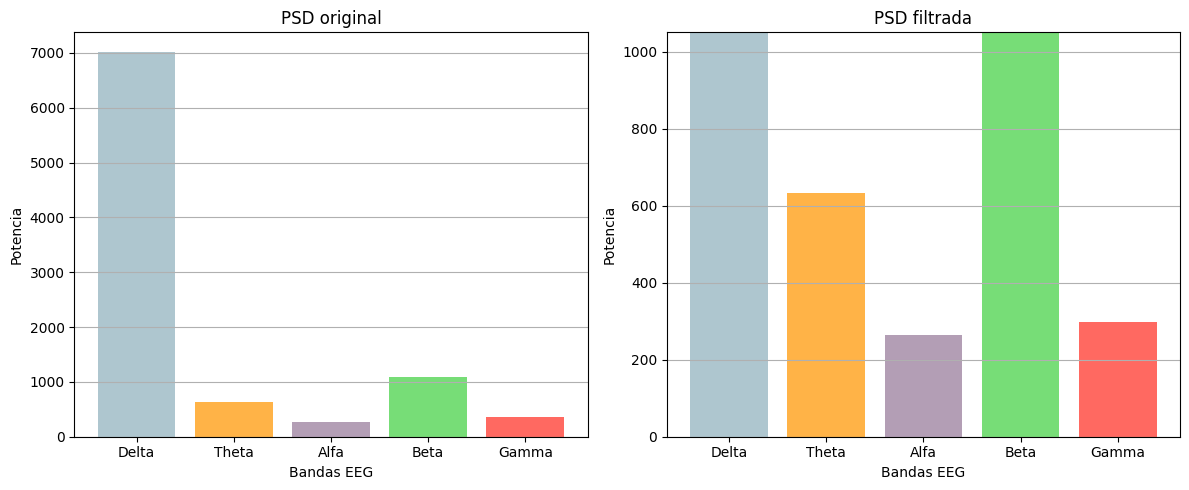

In [70]:
# Cargamos los datos del archivo .txt de OpenSignals
datos = np.loadtxt("Apertura_eyes.txt", delimiter=None, comments="#")
# Señal EEG
eeg = datos[:, 5]

def fft(signal, fs):
    N = len(signal)
    fft_vals = np.fft.rfft(signal)
    fft_mag = np.abs(fft_vals) / N
    fft_db = 20 * np.log10(fft_mag + 1e-12)
    freqs = np.fft.rfftfreq(N, d=1/fs)
    return freqs, fft_mag, fft_db

fs = 100
inicio = 0
fin = int(20 * fs)
eeg_segment = eeg[inicio:fin]

# Tiempo
N = len(eeg_segment)
t = np.arange(N) / fs
eeg_segment = eeg_segment - np.mean(eeg_segment)

# Filtro pasa banda
lowcut = 1
highcut = 40
b, a = butter(4,[lowcut/(fs/2), highcut/(fs/2)],btype='band')
filtered_eeg = filtfilt(b, a, eeg_segment)

# FFT
f_orig, fft_mag_orig, fft_db_orig = fft(eeg_segment,fs)
f_filt, fft_mag_filt, fft_db_filt = fft(filtered_eeg,fs)

# PSD
f_psd_orig, psd_orig = welch(eeg_segment,fs=fs,nperseg=fs*2)
f_psd_filt, psd_filt = welch(filtered_eeg,fs=fs,nperseg=fs*2)

psd_orig_db = 10 * np.log10(psd_orig + 1e-12)
psd_filt_db = 10 * np.log10(psd_filt + 1e-12)

# Gráficos

plt.figure(figsize=(15,10))

# EEG en el tiempo
# sin filtrar
plt.subplot(3,2,1)
plt.plot(t, eeg_segment,'b')
plt.title("EEG original")
plt.xlabel("Tiempo (s)")
plt.ylabel("Amplitud")
plt.grid()

# Filtrada
plt.subplot(3,2,2)
plt.plot(t, filtered_eeg,'m')
plt.title("EEG filtrada (1–40 Hz)")
plt.xlabel("Tiempo (s)")
plt.ylabel("Amplitud")
plt.grid()

# FFT
# sin filtrar
plt.subplot(3,2,3)
plt.plot(f_orig, fft_mag_orig,'b')
plt.title("FFT original")
plt.xlabel("Frecuencia (Hz)")
plt.ylabel("Magnitud")
plt.xlim(0,45)
plt.grid()

# Filtrada
plt.subplot(3,2,4)
plt.plot(f_filt, fft_mag_filt,'m')
plt.title("FFT filtrada")
plt.xlabel("Frecuencia (Hz)")
plt.ylabel("Magnitud")
plt.xlim(0,45)
plt.grid()

# PSD
# sin filtro
plt.subplot(3,2,5)
plt.plot(f_psd_orig, psd_orig_db,'b')
plt.title("PSD original")
plt.xlabel("Frecuencia (Hz)")
plt.ylabel("PSD [dB/Hz]")
plt.xlim(0,45)
plt.grid()

# Filtrada
plt.subplot(3,2,6)
plt.plot(f_psd_filt, psd_filt_db,'m')
plt.title("PSD filtrada")
plt.xlabel("Frecuencia (Hz)")
plt.ylabel("PSD [dB/Hz]")
plt.xlim(0,45)
plt.grid()

plt.tight_layout()
plt.show()

# POTENCIA POR BANDAS
bandas = {"Delta": (0.5, 4), "Theta": (4, 8), "Alfa": (8, 12),
          "Beta": (13, 30),"Gamma": (30, 40)}
potencias_orig = []
potencias_filt = []

for fmin, fmax in bandas.values():

    # sin filtro
    idx_orig = np.logical_and(f_psd_orig >= fmin,f_psd_orig <= fmax)
    potencia_orig = np.trapezoid(psd_orig[idx_orig],f_psd_orig[idx_orig])
    potencias_orig.append(potencia_orig)

    # Filtrada
    idx_filt = np.logical_and(f_psd_filt >= fmin,f_psd_filt <= fmax)
    potencia_filt = np.trapezoid(psd_filt[idx_filt],f_psd_filt[idx_filt])
    potencias_filt.append(potencia_filt)


colores = ["#AEC6CF", "#FFB347", "#B39EB5", "#77DD77", "#FF6961"]
# Psd barras
plt.figure(figsize=(12,5))

#sin filtro
plt.subplot(1,2,1)
plt.bar(bandas.keys(),potencias_orig,color=colores)
plt.title("PSD original")
plt.xlabel("Bandas EEG")
plt.ylabel("Potencia")
plt.grid(axis="y")

# Filtrada
plt.subplot(1,2,2)
plt.bar(bandas.keys(), potencias_filt,color=colores)
plt.title("PSD filtrada")
plt.xlabel("Bandas EEG")
plt.ylabel("Potencia")
plt.grid(axis="y")
plt.ylim(0,1050)
plt.tight_layout()
plt.show()

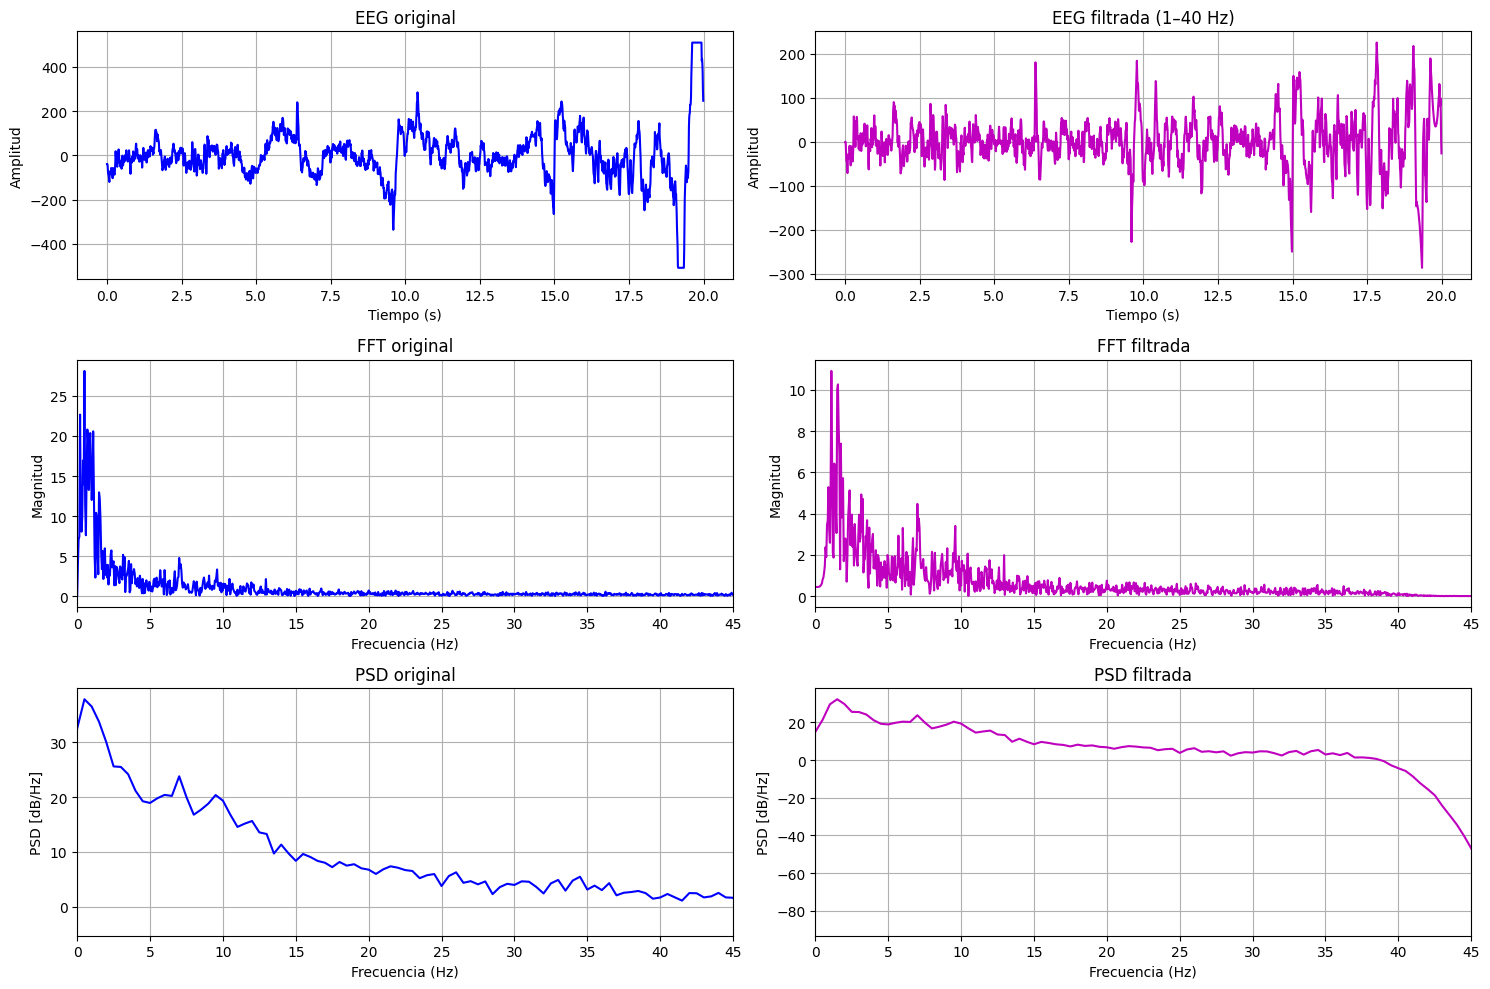

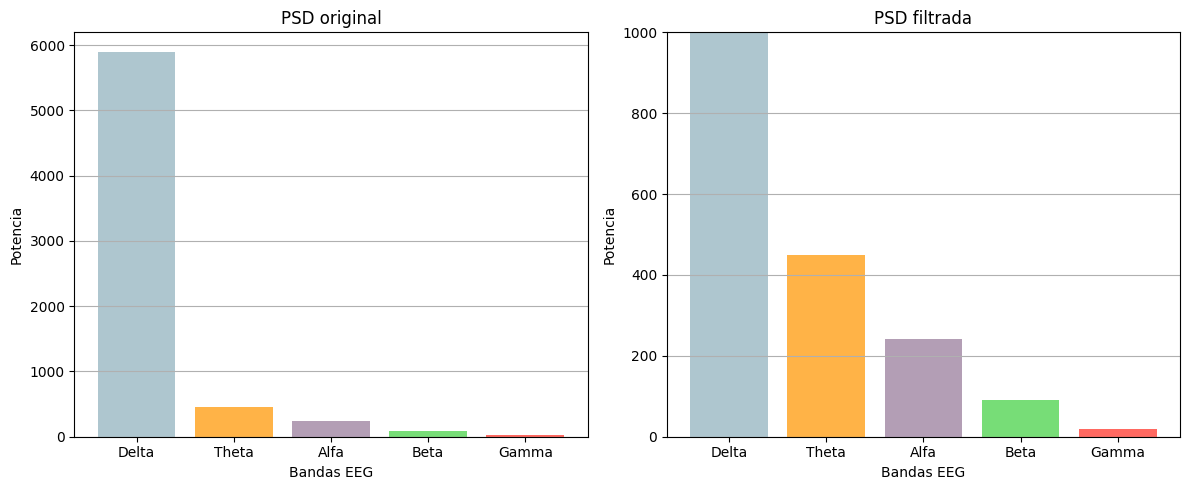

In [71]:
# Cargamos los datos del archivo .txt de OpenSignals
datos = np.loadtxt("Basal_2.txt", delimiter=None, comments="#")
# Señal EEG
eeg = datos[:, 5]

fs = 100
inicio = 0
fin = int(20 * fs)
eeg_segment = eeg[inicio:fin]

# Tiempo
N = len(eeg_segment)
t = np.arange(N) / fs
eeg_segment = eeg_segment - np.mean(eeg_segment)

# Filtro pasa banda
lowcut = 1
highcut = 40
b, a = butter(4,[lowcut/(fs/2), highcut/(fs/2)],btype='band')
filtered_eeg = filtfilt(b, a, eeg_segment)

# FFT
f_orig, fft_mag_orig, fft_db_orig = fft(eeg_segment,fs)
f_filt, fft_mag_filt, fft_db_filt = fft(filtered_eeg,fs)

# PSD
f_psd_orig, psd_orig = welch(eeg_segment,fs=fs,nperseg=fs*2)
f_psd_filt, psd_filt = welch(filtered_eeg,fs=fs,nperseg=fs*2)

psd_orig_db = 10 * np.log10(psd_orig + 1e-12)
psd_filt_db = 10 * np.log10(psd_filt + 1e-12)

# Gráficos

plt.figure(figsize=(15,10))

# EEG en el tiempo
# sin filtrar
plt.subplot(3,2,1)
plt.plot(t, eeg_segment,'b')
plt.title("EEG original")
plt.xlabel("Tiempo (s)")
plt.ylabel("Amplitud")
plt.grid()

# Filtrada
plt.subplot(3,2,2)
plt.plot(t, filtered_eeg,'m')
plt.title("EEG filtrada (1–40 Hz)")
plt.xlabel("Tiempo (s)")
plt.ylabel("Amplitud")
plt.grid()

# FFT
# sin filtrar
plt.subplot(3,2,3)
plt.plot(f_orig, fft_mag_orig,'b')
plt.title("FFT original")
plt.xlabel("Frecuencia (Hz)")
plt.ylabel("Magnitud")
plt.xlim(0,45)
plt.grid()

# Filtrada
plt.subplot(3,2,4)
plt.plot(f_filt, fft_mag_filt,'m')
plt.title("FFT filtrada")
plt.xlabel("Frecuencia (Hz)")
plt.ylabel("Magnitud")
plt.xlim(0,45)
plt.grid()

# PSD
# sin filtro
plt.subplot(3,2,5)
plt.plot(f_psd_orig, psd_orig_db,'b')
plt.title("PSD original")
plt.xlabel("Frecuencia (Hz)")
plt.ylabel("PSD [dB/Hz]")
plt.xlim(0,45)
plt.grid()

# Filtrada
plt.subplot(3,2,6)
plt.plot(f_psd_filt, psd_filt_db,'m')
plt.title("PSD filtrada")
plt.xlabel("Frecuencia (Hz)")
plt.ylabel("PSD [dB/Hz]")
plt.xlim(0,45)
plt.grid()

plt.tight_layout()
plt.show()

# POTENCIA POR BANDAS
bandas = {"Delta": (0.5, 4), "Theta": (4, 8), "Alfa": (8, 12),
          "Beta": (13, 30),"Gamma": (30, 40)}
potencias_orig = []
potencias_filt = []

for fmin, fmax in bandas.values():

    # sin filtro
    idx_orig = np.logical_and(f_psd_orig >= fmin,f_psd_orig <= fmax)
    potencia_orig = np.trapezoid(psd_orig[idx_orig],f_psd_orig[idx_orig])
    potencias_orig.append(potencia_orig)

    # Filtrada
    idx_filt = np.logical_and(f_psd_filt >= fmin,f_psd_filt <= fmax)
    potencia_filt = np.trapezoid(psd_filt[idx_filt],f_psd_filt[idx_filt])
    potencias_filt.append(potencia_filt)


colores = ["#AEC6CF", "#FFB347", "#B39EB5", "#77DD77", "#FF6961"]
# Psd barras
plt.figure(figsize=(12,5))

#sin filtro
plt.subplot(1,2,1)
plt.bar(bandas.keys(),potencias_orig,color=colores)
plt.title("PSD original")
plt.xlabel("Bandas EEG")
plt.ylabel("Potencia")
plt.grid(axis="y")

# Filtrada
plt.subplot(1,2,2)
plt.bar(bandas.keys(), potencias_filt,color=colores)
plt.title("PSD filtrada")
plt.xlabel("Bandas EEG")
plt.ylabel("Potencia")
plt.grid(axis="y")
plt.ylim(0,1000)
plt.tight_layout()
plt.show()

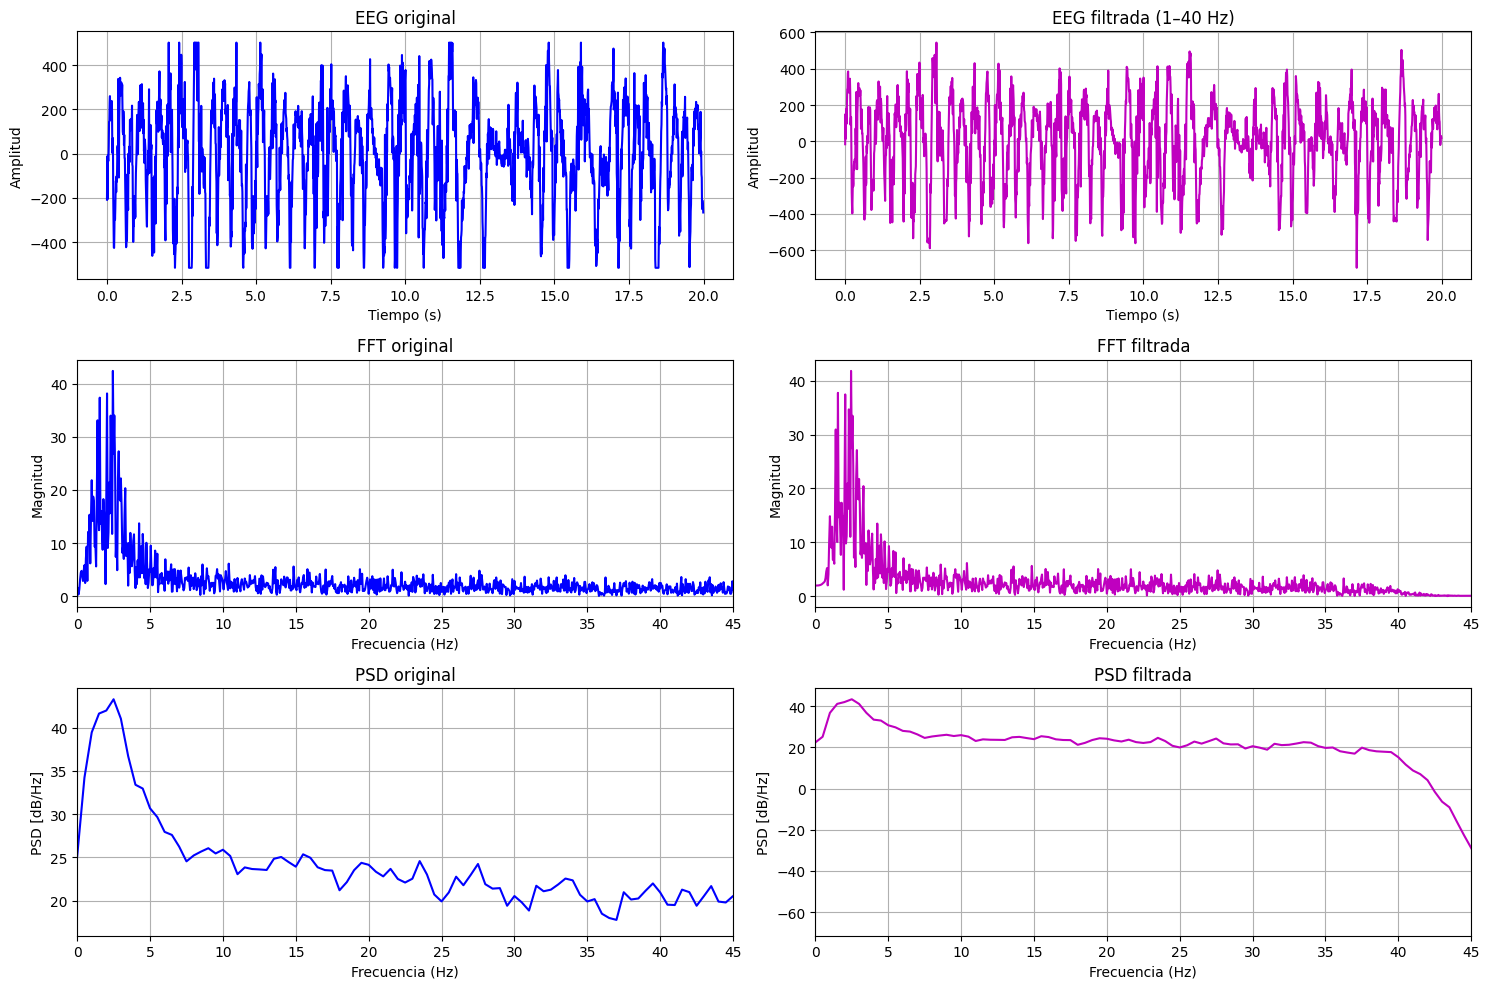

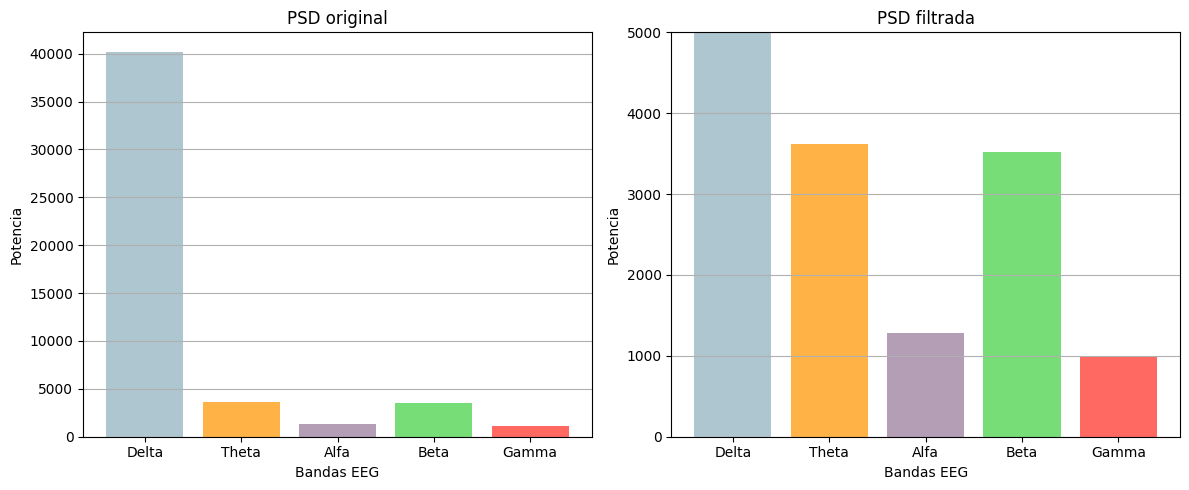

In [69]:
# Cargamos los datos del archivo .txt de OpenSignals
datos = np.loadtxt("Masticacion.txt", delimiter=None, comments="#")
# Señal EEG
eeg = datos[:, 5]

def fft(signal, fs):
    N = len(signal)
    fft_vals = np.fft.rfft(signal)
    fft_mag = np.abs(fft_vals) / N
    fft_db = 20 * np.log10(fft_mag + 1e-12)
    freqs = np.fft.rfftfreq(N, d=1/fs)
    return freqs, fft_mag, fft_db

fs = 100
inicio = 0
fin = int(20 * fs)
eeg_segment = eeg[inicio:fin]

# Tiempo
N = len(eeg_segment)
t = np.arange(N) / fs
eeg_segment = eeg_segment - np.mean(eeg_segment)

# Filtro pasa banda
lowcut = 1
highcut = 40
b, a = butter(4,[lowcut/(fs/2), highcut/(fs/2)],btype='band')
filtered_eeg = filtfilt(b, a, eeg_segment)

# FFT
f_orig, fft_mag_orig, fft_db_orig = fft(eeg_segment,fs)
f_filt, fft_mag_filt, fft_db_filt = fft(filtered_eeg,fs)

# PSD
f_psd_orig, psd_orig = welch(eeg_segment,fs=fs,nperseg=fs*2)
f_psd_filt, psd_filt = welch(filtered_eeg,fs=fs,nperseg=fs*2)

psd_orig_db = 10 * np.log10(psd_orig + 1e-12)
psd_filt_db = 10 * np.log10(psd_filt + 1e-12)

# Gráficos

plt.figure(figsize=(15,10))

# EEG en el tiempo
# sin filtrar
plt.subplot(3,2,1)
plt.plot(t, eeg_segment,'b')
plt.title("EEG original")
plt.xlabel("Tiempo (s)")
plt.ylabel("Amplitud")
plt.grid()

# Filtrada
plt.subplot(3,2,2)
plt.plot(t, filtered_eeg,'m')
plt.title("EEG filtrada (1–40 Hz)")
plt.xlabel("Tiempo (s)")
plt.ylabel("Amplitud")
plt.grid()

# FFT
# sin filtrar
plt.subplot(3,2,3)
plt.plot(f_orig, fft_mag_orig,'b')
plt.title("FFT original")
plt.xlabel("Frecuencia (Hz)")
plt.ylabel("Magnitud")
plt.xlim(0,45)
plt.grid()

# Filtrada
plt.subplot(3,2,4)
plt.plot(f_filt, fft_mag_filt,'m')
plt.title("FFT filtrada")
plt.xlabel("Frecuencia (Hz)")
plt.ylabel("Magnitud")
plt.xlim(0,45)
plt.grid()

# PSD
# sin filtro
plt.subplot(3,2,5)
plt.plot(f_psd_orig, psd_orig_db,'b')
plt.title("PSD original")
plt.xlabel("Frecuencia (Hz)")
plt.ylabel("PSD [dB/Hz]")
plt.xlim(0,45)
plt.grid()

# Filtrada
plt.subplot(3,2,6)
plt.plot(f_psd_filt, psd_filt_db,'m')
plt.title("PSD filtrada")
plt.xlabel("Frecuencia (Hz)")
plt.ylabel("PSD [dB/Hz]")
plt.xlim(0,45)
plt.grid()

plt.tight_layout()
plt.show()

# POTENCIA POR BANDAS
bandas = {"Delta": (0.5, 4), "Theta": (4, 8), "Alfa": (8, 12),
          "Beta": (13, 30),"Gamma": (30, 40)}
potencias_orig = []
potencias_filt = []

for fmin, fmax in bandas.values():

    # sin filtro
    idx_orig = np.logical_and(f_psd_orig >= fmin,f_psd_orig <= fmax)
    potencia_orig = np.trapezoid(psd_orig[idx_orig],f_psd_orig[idx_orig])
    potencias_orig.append(potencia_orig)

    # Filtrada
    idx_filt = np.logical_and(f_psd_filt >= fmin,f_psd_filt <= fmax)
    potencia_filt = np.trapezoid(psd_filt[idx_filt],f_psd_filt[idx_filt])
    potencias_filt.append(potencia_filt)


colores = ["#AEC6CF", "#FFB347", "#B39EB5", "#77DD77", "#FF6961"]
# Psd barras
plt.figure(figsize=(12,5))

#sin filtro
plt.subplot(1,2,1)
plt.bar(bandas.keys(),potencias_orig,color=colores)
plt.title("PSD original")
plt.xlabel("Bandas EEG")
plt.ylabel("Potencia")
plt.grid(axis="y")

# Filtrada
plt.subplot(1,2,2)
plt.bar(bandas.keys(), potencias_filt,color=colores)
plt.title("PSD filtrada")
plt.xlabel("Bandas EEG")
plt.ylabel("Potencia")
plt.grid(axis="y")
plt.ylim(0,5000)
plt.tight_layout()
plt.show()

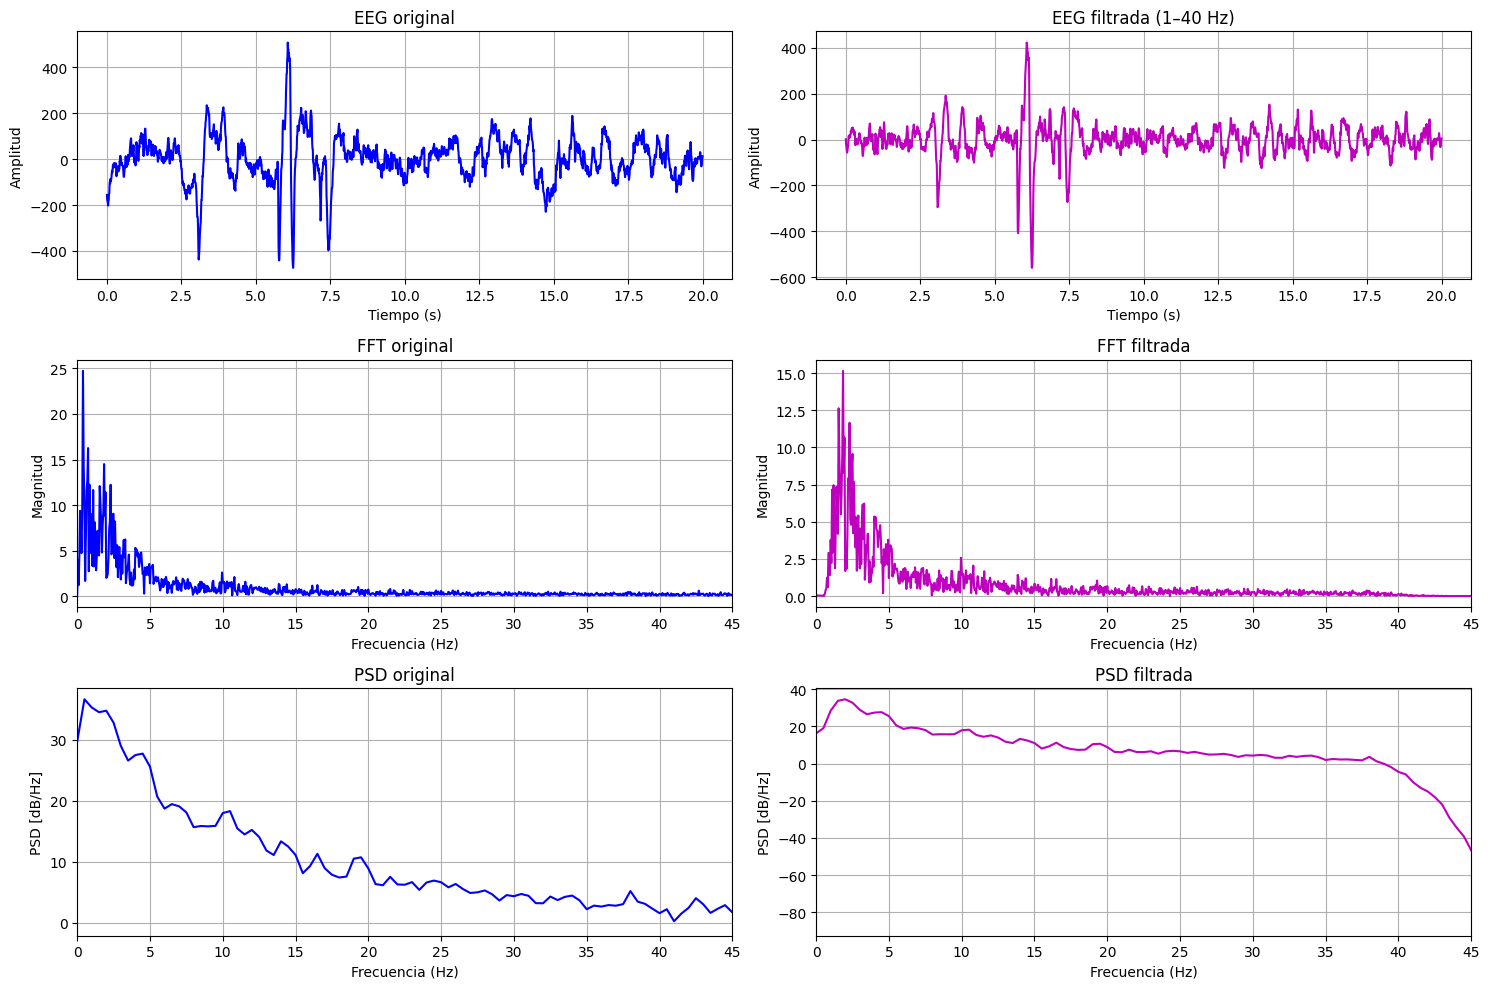

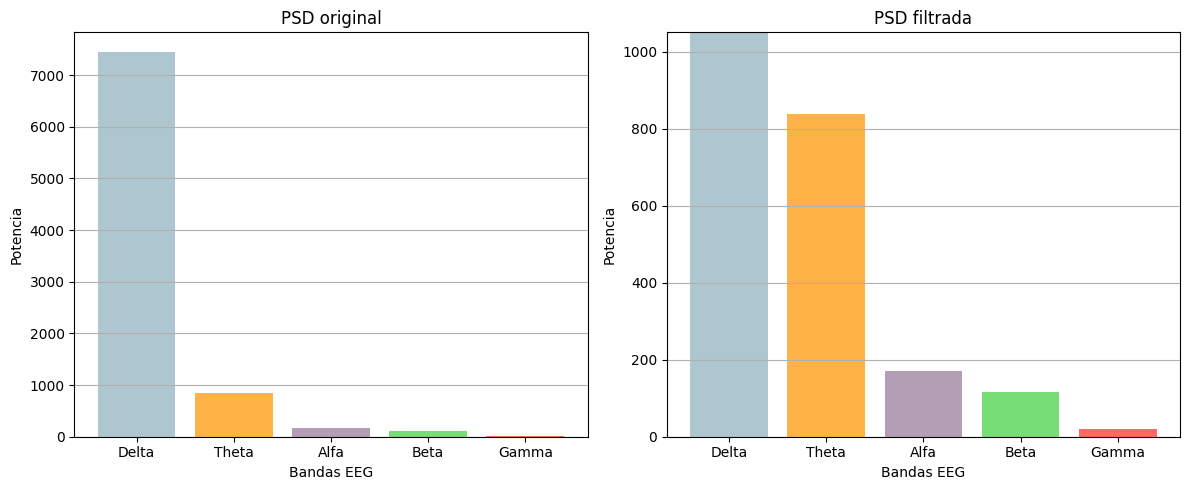

In [67]:
# Cargamos los datos del archivo .txt de OpenSignals
datos = np.loadtxt("basal_3.txt", delimiter=None, comments="#")
# Señal EEG
eeg = datos[:, 5]

def fft(signal, fs):
    N = len(signal)
    fft_vals = np.fft.rfft(signal)
    fft_mag = np.abs(fft_vals) / N
    fft_db = 20 * np.log10(fft_mag + 1e-12)
    freqs = np.fft.rfftfreq(N, d=1/fs)
    return freqs, fft_mag, fft_db

fs = 100
inicio = 0
fin = int(20 * fs)
eeg_segment = eeg[inicio:fin]

# Tiempo
N = len(eeg_segment)
t = np.arange(N) / fs
eeg_segment = eeg_segment - np.mean(eeg_segment)

# Filtro pasa banda
lowcut = 1
highcut = 40
b, a = butter(4,[lowcut/(fs/2), highcut/(fs/2)],btype='band')
filtered_eeg = filtfilt(b, a, eeg_segment)

# FFT
f_orig, fft_mag_orig, fft_db_orig = fft(eeg_segment,fs)
f_filt, fft_mag_filt, fft_db_filt = fft(filtered_eeg,fs)

# PSD
f_psd_orig, psd_orig = welch(eeg_segment,fs=fs,nperseg=fs*2)
f_psd_filt, psd_filt = welch(filtered_eeg,fs=fs,nperseg=fs*2)

psd_orig_db = 10 * np.log10(psd_orig + 1e-12)
psd_filt_db = 10 * np.log10(psd_filt + 1e-12)

# Gráficos

plt.figure(figsize=(15,10))

# EEG en el tiempo
# sin filtrar
plt.subplot(3,2,1)
plt.plot(t, eeg_segment,'b')
plt.title("EEG original")
plt.xlabel("Tiempo (s)")
plt.ylabel("Amplitud")
plt.grid()

# Filtrada
plt.subplot(3,2,2)
plt.plot(t, filtered_eeg,'m')
plt.title("EEG filtrada (1–40 Hz)")
plt.xlabel("Tiempo (s)")
plt.ylabel("Amplitud")
plt.grid()

# FFT
# sin filtrar
plt.subplot(3,2,3)
plt.plot(f_orig, fft_mag_orig,'b')
plt.title("FFT original")
plt.xlabel("Frecuencia (Hz)")
plt.ylabel("Magnitud")
plt.xlim(0,45)
plt.grid()

# Filtrada
plt.subplot(3,2,4)
plt.plot(f_filt, fft_mag_filt,'m')
plt.title("FFT filtrada")
plt.xlabel("Frecuencia (Hz)")
plt.ylabel("Magnitud")
plt.xlim(0,45)
plt.grid()

# PSD
# sin filtro
plt.subplot(3,2,5)
plt.plot(f_psd_orig, psd_orig_db,'b')
plt.title("PSD original")
plt.xlabel("Frecuencia (Hz)")
plt.ylabel("PSD [dB/Hz]")
plt.xlim(0,45)
plt.grid()

# Filtrada
plt.subplot(3,2,6)
plt.plot(f_psd_filt, psd_filt_db,'m')
plt.title("PSD filtrada")
plt.xlabel("Frecuencia (Hz)")
plt.ylabel("PSD [dB/Hz]")
plt.xlim(0,45)
plt.grid()

plt.tight_layout()
plt.show()

# POTENCIA POR BANDAS
bandas = {"Delta": (0.5, 4), "Theta": (4, 8), "Alfa": (8, 12),
          "Beta": (13, 30),"Gamma": (30, 40)}
potencias_orig = []
potencias_filt = []

for fmin, fmax in bandas.values():

    # sin filtro
    idx_orig = np.logical_and(f_psd_orig >= fmin,f_psd_orig <= fmax)
    potencia_orig = np.trapezoid(psd_orig[idx_orig],f_psd_orig[idx_orig])
    potencias_orig.append(potencia_orig)

    # Filtrada
    idx_filt = np.logical_and(f_psd_filt >= fmin,f_psd_filt <= fmax)
    potencia_filt = np.trapezoid(psd_filt[idx_filt],f_psd_filt[idx_filt])
    potencias_filt.append(potencia_filt)


colores = ["#AEC6CF", "#FFB347", "#B39EB5", "#77DD77", "#FF6961"]
# Psd barras
plt.figure(figsize=(12,5))

#sin filtro
plt.subplot(1,2,1)
plt.bar(bandas.keys(),potencias_orig,color=colores)
plt.title("PSD original")
plt.xlabel("Bandas EEG")
plt.ylabel("Potencia")
plt.grid(axis="y")

# Filtrada
plt.subplot(1,2,2)
plt.bar(bandas.keys(), potencias_filt,color=colores)
plt.title("PSD filtrada")
plt.xlabel("Bandas EEG")
plt.ylabel("Potencia")
plt.grid(axis="y")
plt.ylim(0,1050)
plt.tight_layout()
plt.show()

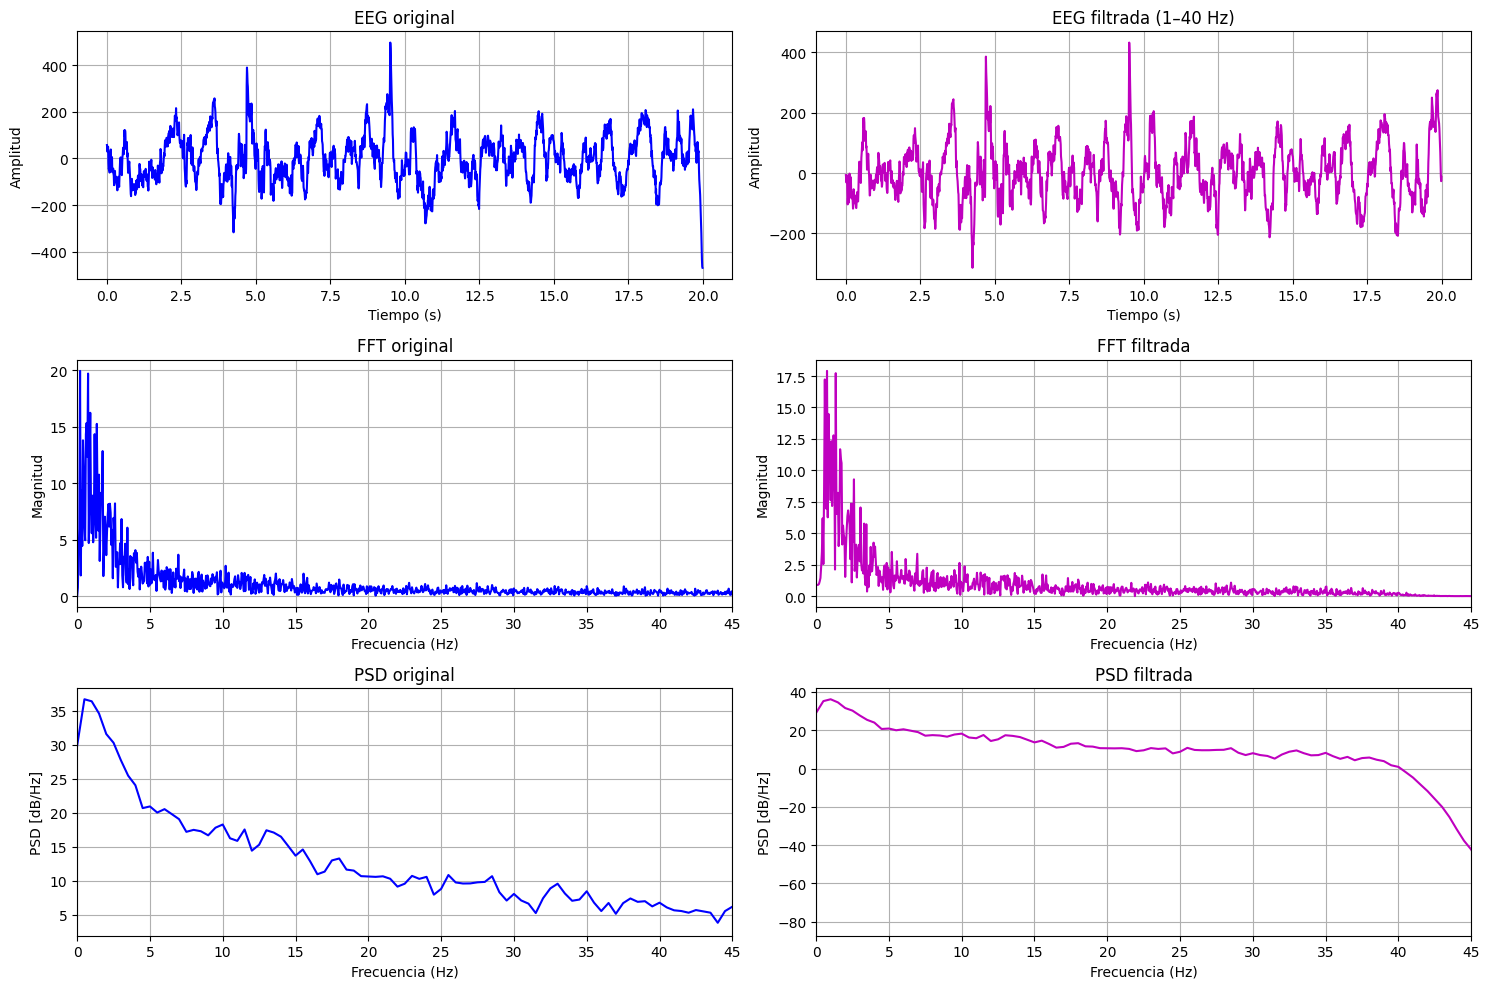

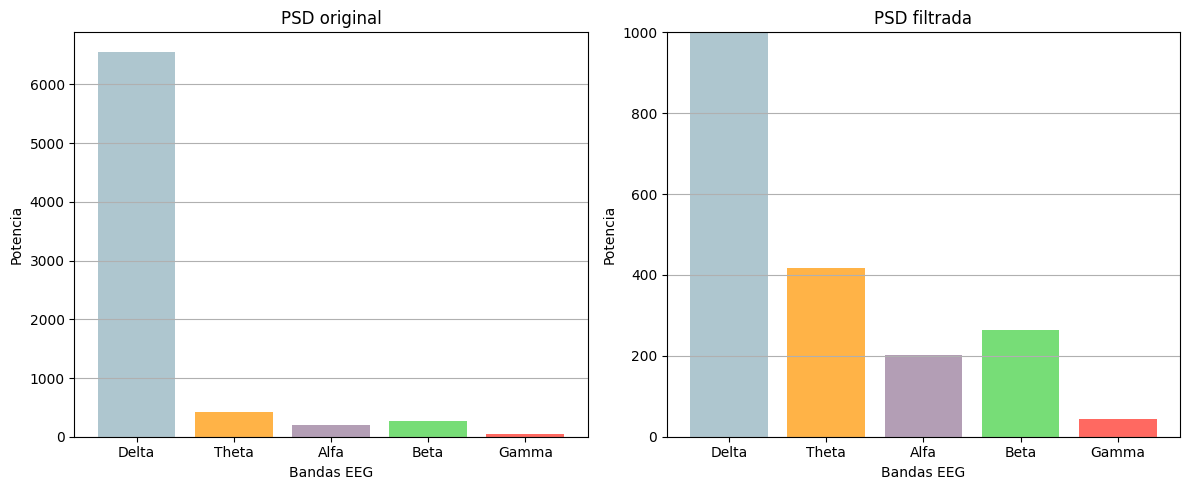

In [65]:
# Cargamos los datos del archivo .txt de OpenSignals
datos = np.loadtxt("Musica_estresante.txt", delimiter=None, comments="#")
# Señal EEG
eeg = datos[:, 5]

def fft(signal, fs):
    N = len(signal)
    fft_vals = np.fft.rfft(signal)
    fft_mag = np.abs(fft_vals) / N
    fft_db = 20 * np.log10(fft_mag + 1e-12)
    freqs = np.fft.rfftfreq(N, d=1/fs)
    return freqs, fft_mag, fft_db

fs = 100
inicio = 0
fin = int(20 * fs)
eeg_segment = eeg[inicio:fin]

# Tiempo
N = len(eeg_segment)
t = np.arange(N) / fs
eeg_segment = eeg_segment - np.mean(eeg_segment)

# Filtro pasa banda
lowcut = 0.5
highcut = 40
b, a = butter(4,[lowcut/(fs/2), highcut/(fs/2)],btype='band')
filtered_eeg = filtfilt(b, a, eeg_segment)

# FFT
f_orig, fft_mag_orig, fft_db_orig = fft(eeg_segment,fs)
f_filt, fft_mag_filt, fft_db_filt = fft(filtered_eeg,fs)

# PSD
f_psd_orig, psd_orig = welch(eeg_segment,fs=fs,nperseg=fs*2)
f_psd_filt, psd_filt = welch(filtered_eeg,fs=fs,nperseg=fs*2)

psd_orig_db = 10 * np.log10(psd_orig + 1e-12)
psd_filt_db = 10 * np.log10(psd_filt + 1e-12)

# Gráficos

plt.figure(figsize=(15,10))

# EEG en el tiempo
# sin filtrar
plt.subplot(3,2,1)
plt.plot(t, eeg_segment,'b')
plt.title("EEG original")
plt.xlabel("Tiempo (s)")
plt.ylabel("Amplitud")
plt.grid()

# Filtrada
plt.subplot(3,2,2)
plt.plot(t, filtered_eeg,'m')
plt.title("EEG filtrada (1–40 Hz)")
plt.xlabel("Tiempo (s)")
plt.ylabel("Amplitud")
plt.grid()

# FFT
# sin filtrar
plt.subplot(3,2,3)
plt.plot(f_orig, fft_mag_orig,'b')
plt.title("FFT original")
plt.xlabel("Frecuencia (Hz)")
plt.ylabel("Magnitud")
plt.xlim(0,45)
plt.grid()

# Filtrada
plt.subplot(3,2,4)
plt.plot(f_filt, fft_mag_filt,'m')
plt.title("FFT filtrada")
plt.xlabel("Frecuencia (Hz)")
plt.ylabel("Magnitud")
plt.xlim(0,45)
plt.grid()

# PSD
# sin filtro
plt.subplot(3,2,5)
plt.plot(f_psd_orig, psd_orig_db,'b')
plt.title("PSD original")
plt.xlabel("Frecuencia (Hz)")
plt.ylabel("PSD [dB/Hz]")
plt.xlim(0,45)
plt.grid()

# Filtrada
plt.subplot(3,2,6)
plt.plot(f_psd_filt, psd_filt_db,'m')
plt.title("PSD filtrada")
plt.xlabel("Frecuencia (Hz)")
plt.ylabel("PSD [dB/Hz]")
plt.xlim(0,45)
plt.grid()

plt.tight_layout()
plt.show()

# POTENCIA POR BANDAS
bandas = {"Delta": (0.5, 4), "Theta": (4, 8), "Alfa": (8, 12),
          "Beta": (13, 30),"Gamma": (30, 40)}
potencias_orig = []
potencias_filt = []

for fmin, fmax in bandas.values():

    # sin filtro
    idx_orig = np.logical_and(f_psd_orig >= fmin,f_psd_orig <= fmax)
    potencia_orig = np.trapezoid(psd_orig[idx_orig],f_psd_orig[idx_orig])
    potencias_orig.append(potencia_orig)

    # Filtrada
    idx_filt = np.logical_and(f_psd_filt >= fmin,f_psd_filt <= fmax)
    potencia_filt = np.trapezoid(psd_filt[idx_filt],f_psd_filt[idx_filt])
    potencias_filt.append(potencia_filt)


colores = ["#AEC6CF", "#FFB347", "#B39EB5", "#77DD77", "#FF6961"]
# Psd barras
plt.figure(figsize=(12,5))

#sin filtro
plt.subplot(1,2,1)
plt.bar(bandas.keys(),potencias_orig,color=colores)
plt.title("PSD original")
plt.xlabel("Bandas EEG")
plt.ylabel("Potencia")
plt.grid(axis="y")

# Filtrada
plt.subplot(1,2,2)
plt.bar(bandas.keys(), potencias_filt,color=colores)
plt.title("PSD filtrada")
plt.xlabel("Bandas EEG")
plt.ylabel("Potencia")
plt.grid(axis="y")
plt.ylim(0,1000)
plt.tight_layout()
plt.show()

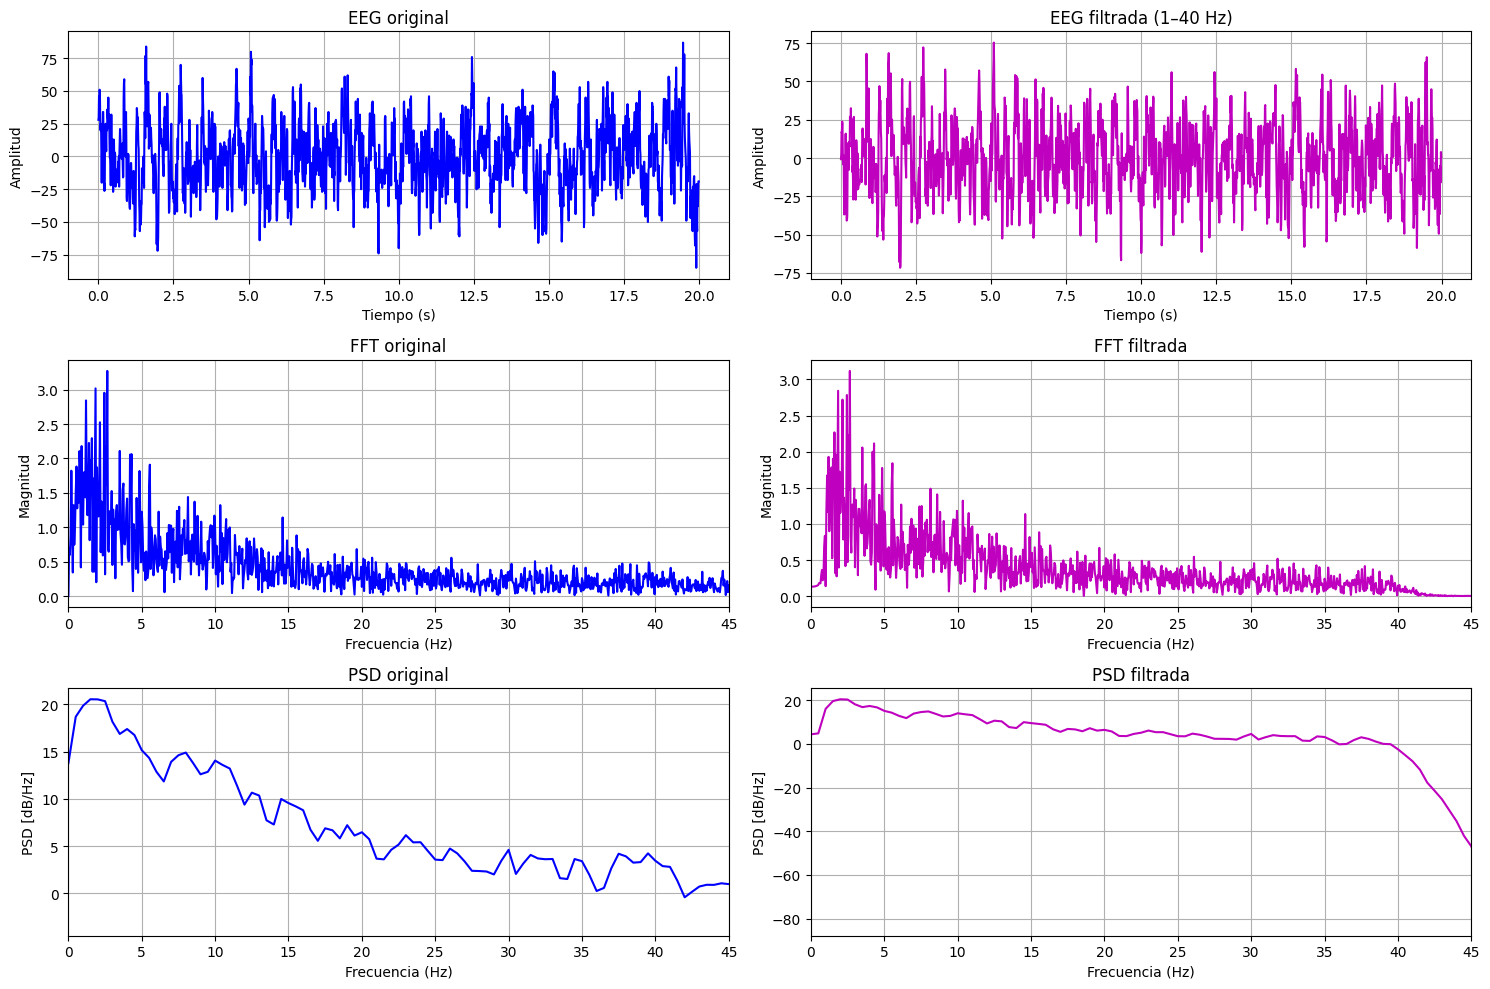

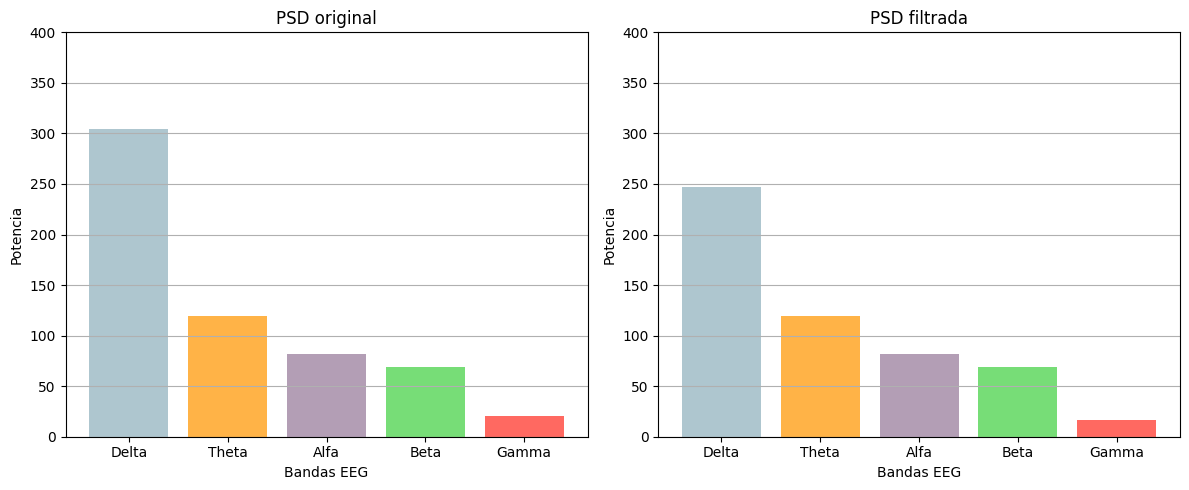

In [66]:
# Cargamos los datos del archivo .txt de OpenSignals
datos = np.loadtxt("Musica_relajante.txt", delimiter=None, comments="#")
# Señal EEG
eeg = datos[:, 5]

def fft(signal, fs):
    N = len(signal)
    fft_vals = np.fft.rfft(signal)
    fft_mag = np.abs(fft_vals) / N
    fft_db = 20 * np.log10(fft_mag + 1e-12)
    freqs = np.fft.rfftfreq(N, d=1/fs)
    return freqs, fft_mag, fft_db

fs = 100
inicio = 0
fin = int(20 * fs)
eeg_segment = eeg[inicio:fin]

# Tiempo
N = len(eeg_segment)
t = np.arange(N) / fs
eeg_segment = eeg_segment - np.mean(eeg_segment)

# Filtro pasa banda
lowcut = 1
highcut = 40
b, a = butter(4,[lowcut/(fs/2), highcut/(fs/2)],btype='band')
filtered_eeg = filtfilt(b, a, eeg_segment)

# FFT
f_orig, fft_mag_orig, fft_db_orig = fft(eeg_segment,fs)
f_filt, fft_mag_filt, fft_db_filt = fft(filtered_eeg,fs)

# PSD
f_psd_orig, psd_orig = welch(eeg_segment,fs=fs,nperseg=fs*2)
f_psd_filt, psd_filt = welch(filtered_eeg,fs=fs,nperseg=fs*2)

psd_orig_db = 10 * np.log10(psd_orig + 1e-12)
psd_filt_db = 10 * np.log10(psd_filt + 1e-12)

# Gráficos

plt.figure(figsize=(15,10))

# EEG en el tiempo
# sin filtrar
plt.subplot(3,2,1)
plt.plot(t, eeg_segment,'b')
plt.title("EEG original")
plt.xlabel("Tiempo (s)")
plt.ylabel("Amplitud")
plt.grid()

# Filtrada
plt.subplot(3,2,2)
plt.plot(t, filtered_eeg,'m')
plt.title("EEG filtrada (1–40 Hz)")
plt.xlabel("Tiempo (s)")
plt.ylabel("Amplitud")
plt.grid()

# FFT
# sin filtrar
plt.subplot(3,2,3)
plt.plot(f_orig, fft_mag_orig,'b')
plt.title("FFT original")
plt.xlabel("Frecuencia (Hz)")
plt.ylabel("Magnitud")
plt.xlim(0,45)
plt.grid()

# Filtrada
plt.subplot(3,2,4)
plt.plot(f_filt, fft_mag_filt,'m')
plt.title("FFT filtrada")
plt.xlabel("Frecuencia (Hz)")
plt.ylabel("Magnitud")
plt.xlim(0,45)
plt.grid()

# PSD
# sin filtro
plt.subplot(3,2,5)
plt.plot(f_psd_orig, psd_orig_db,'b')
plt.title("PSD original")
plt.xlabel("Frecuencia (Hz)")
plt.ylabel("PSD [dB/Hz]")
plt.xlim(0,45)
plt.grid()

# Filtrada
plt.subplot(3,2,6)
plt.plot(f_psd_filt, psd_filt_db,'m')
plt.title("PSD filtrada")
plt.xlabel("Frecuencia (Hz)")
plt.ylabel("PSD [dB/Hz]")
plt.xlim(0,45)
plt.grid()

plt.tight_layout()
plt.show()

# POTENCIA POR BANDAS
bandas = {"Delta": (0.5, 4), "Theta": (4, 8), "Alfa": (8, 12),
          "Beta": (13, 30),"Gamma": (30, 40)}
potencias_orig = []
potencias_filt = []

for fmin, fmax in bandas.values():

    # sin filtro
    idx_orig = np.logical_and(f_psd_orig >= fmin,f_psd_orig <= fmax)
    potencia_orig = np.trapezoid(psd_orig[idx_orig],f_psd_orig[idx_orig])
    potencias_orig.append(potencia_orig)

    # Filtrada
    idx_filt = np.logical_and(f_psd_filt >= fmin,f_psd_filt <= fmax)
    potencia_filt = np.trapezoid(psd_filt[idx_filt],f_psd_filt[idx_filt])
    potencias_filt.append(potencia_filt)


colores = ["#AEC6CF", "#FFB347", "#B39EB5", "#77DD77", "#FF6961"]
# Psd barras
plt.figure(figsize=(12,5))

#sin filtro
plt.subplot(1,2,1)
plt.bar(bandas.keys(),potencias_orig,color=colores)
plt.title("PSD original")
plt.xlabel("Bandas EEG")
plt.ylabel("Potencia")
plt.ylim(0,400)
plt.grid(axis="y")

# Filtrada
plt.subplot(1,2,2)
plt.bar(bandas.keys(), potencias_filt,color=colores)
plt.title("PSD filtrada")
plt.xlabel("Bandas EEG")
plt.ylabel("Potencia")
plt.grid(axis="y")
plt.ylim(0,400)
plt.tight_layout()
plt.show()